In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import load_application_train

df = load_application_train()

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))

Dataset shape: (307511, 122)
Columns: 122


In [2]:
target_counts = df["TARGET"].value_counts()

print("Non-default (0):", target_counts[0])
print("Default (1):", target_counts[1])

print("\nDefault rate:")
print(df["TARGET"].mean())

Non-default (0): 282686
Default (1): 24825

Default rate:
0.08072881945686496


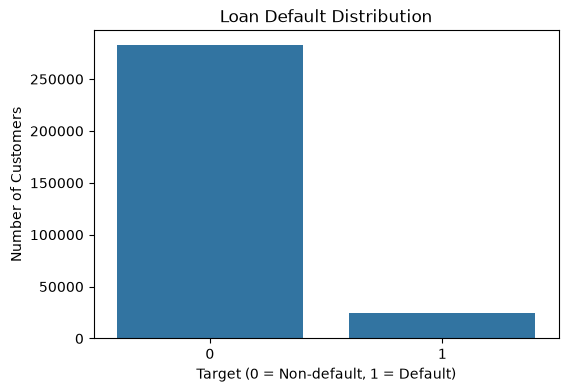

In [3]:
plt.figure(figsize=(6, 4))

sns.countplot(x="TARGET", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Number of Customers")

plt.show()

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Number of numerical columns:", len(numeric_cols))

df[numeric_cols].describe().T.head(15)

Number of numerical columns: 106


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.00000,189145.500000,278202.00000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.00000,0.000000,0.00000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.00000,0.000000,0.00000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.00000,112500.000000,147150.00000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.00000,270000.000000,513531.00000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.50000,16524.000000,24903.00000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.00000,238500.000000,450000.00000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,0.00029,0.010006,0.01885,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.00000,-19682.000000,-15750.00000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.00000,-2760.000000,-1213.00000,-289.000000,3.652430e+05


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percent", ascending=False)

missing_summary.head(15)

,missing_count,missing_percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


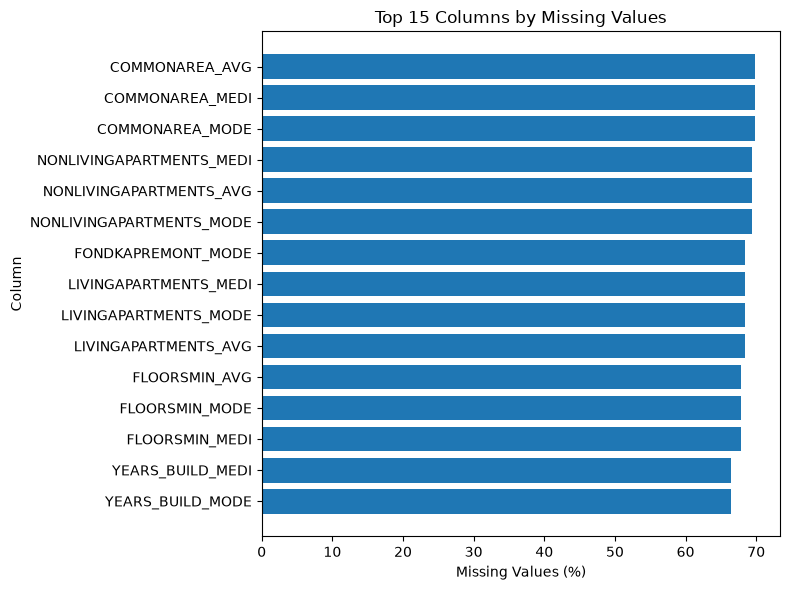

In [6]:
top_missing = missing_summary.head(15).sort_values("missing_percent")

plt.figure(figsize=(8, 6))

plt.barh(
    top_missing.index,
    top_missing["missing_percent"]
)

plt.title("Top 15 Columns by Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

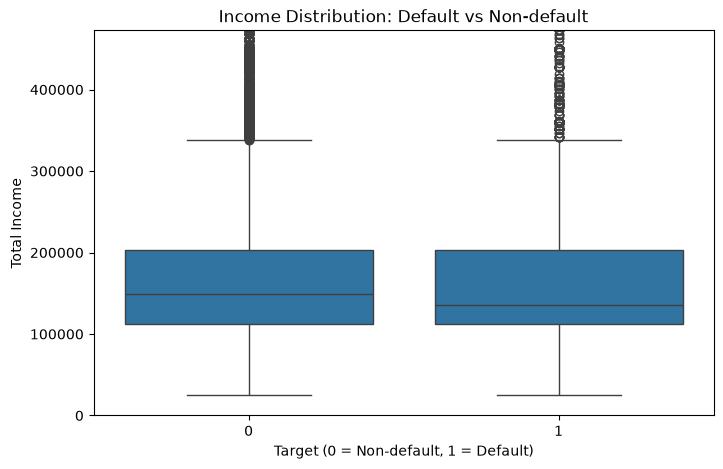

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="AMT_INCOME_TOTAL",
    data=df
)

plt.title("Income Distribution: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Total Income")

plt.ylim(0, df["AMT_INCOME_TOTAL"].quantile(0.99))

plt.show()

### Insight: Income and Loan Default

One important observation from this chart is that the income distributions of defaulters and non-defaulters overlap significantly. This indicates that income alone is not sufficient to predict loan default, and we will need to combine multiple features to build an effective predictive model.

C:\Users\Dell\AppData\Local\Temp\ipykernel_8200\2557172122.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_YEARS"] = (-df["DAYS_BIRTH"]) / 365.25


count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64


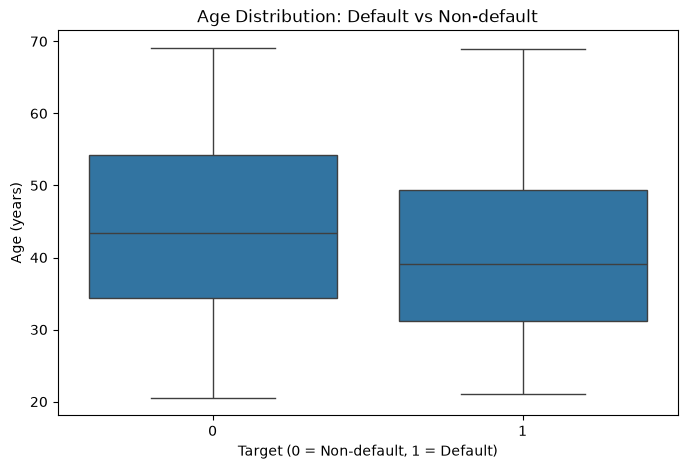

In [8]:
df["AGE_YEARS"] = (-df["DAYS_BIRTH"]) / 365.25

print(df["AGE_YEARS"].describe())

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="AGE_YEARS",
    data=df
)

plt.title("Age Distribution: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Age (years)")

plt.show()

In [9]:
df["AGE_YEARS"] = (-df["DAYS_BIRTH"]) / 365.25

print(df["AGE_YEARS"].describe())

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64


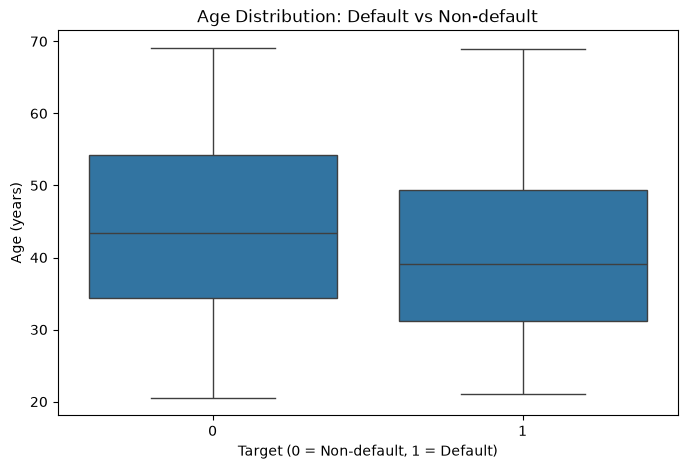

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="AGE_YEARS",
    data=df
)

plt.title("Age Distribution: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Age (years)")

plt.show()

### Insight: Age and Loan Default

The age distributions of defaulters and non-defaulters show some differences, although there is considerable overlap between the two groups. This suggests that age may provide useful information for predicting loan default, but it is not sufficient on its own. Combining age with other financial and demographic features should improve the model's predictive ability.

In [11]:
contract_summary = pd.crosstab(
    df["NAME_CONTRACT_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

contract_summary

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,91.654087,8.345913
Revolving loans,94.521671,5.478329


### Insight: Loan Contract Type and Default

The default rate differs across loan contract types. Cash loans have a higher default rate (approximately 8.35%) compared with revolving loans (approximately 5.48%). This suggests that the type of loan contract may contain useful information for predicting loan default.

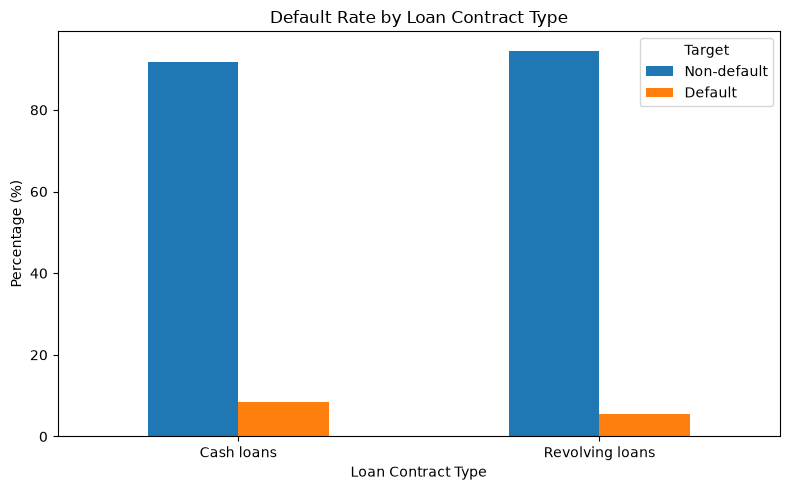

In [12]:
contract_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Default Rate by Loan Contract Type")
plt.xlabel("Loan Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Target",
    labels=["Non-default", "Default"]
)

plt.tight_layout()
plt.show()

In [13]:
gender_summary = pd.crosstab(
    df["CODE_GENDER"],
    df["TARGET"],
    normalize="index"
) * 100

gender_summary

TARGET,0,1
CODE_GENDER,,
F,93.000672,6.999328
M,89.858080,10.141920
XNA,100.000000,0.000000


### Insight: Gender and Loan Default

The default rate differs across gender categories. Male applicants have a higher default rate (approximately 10.14%) compared with female applicants (approximately 7.00%). This suggests that gender may contain useful information for predicting loan default. However, the XNA category is extremely rare and should not be over-interpreted.

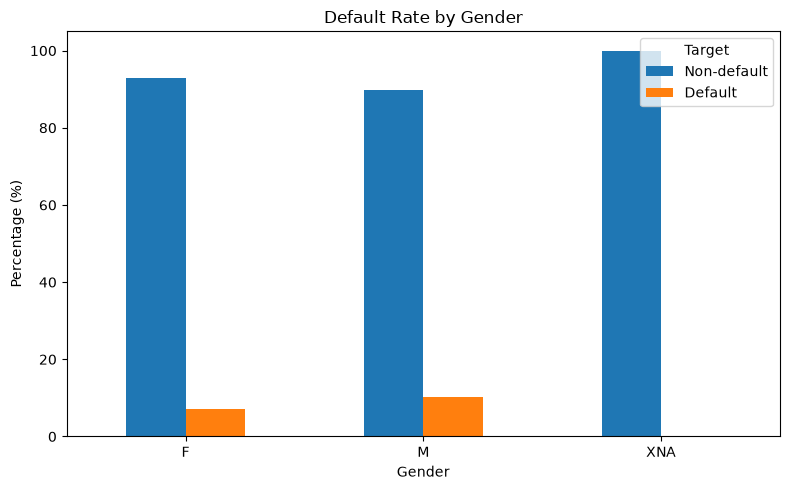

In [14]:
gender_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Target",
    labels=["Non-default", "Default"]
)

plt.tight_layout()
plt.show()

In [15]:
education_summary = pd.crosstab(
    df["NAME_EDUCATION_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

education_summary.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
NAME_EDUCATION_TYPE,,
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929
Incomplete higher,91.515034,8.484966
Higher education,94.644885,5.355115
Academic degree,98.170732,1.829268


### Insight: Education Level and Loan Default

The default rate varies substantially across education levels. Applicants with lower secondary education have the highest observed default rate (approximately 10.93%), while applicants with an academic degree have the lowest rate (approximately 1.83%). Overall, higher education levels are associated with lower observed default rates in this dataset. However, this is an observed relationship and does not imply causation.

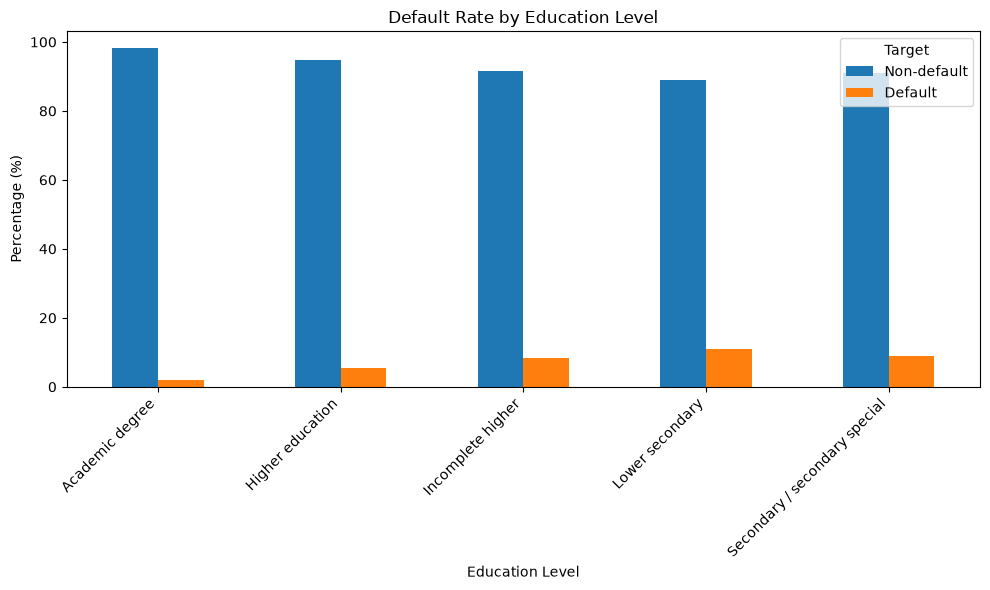

In [16]:
education_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Target",
    labels=["Non-default", "Default"]
)

plt.tight_layout()
plt.show()

In [17]:
df["LOAN_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

print(df["LOAN_INCOME_RATIO"].describe())

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: LOAN_INCOME_RATIO, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_8200\190398324.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["LOAN_INCOME_RATIO"] = (


### Insight: Education Level and Loan Default

The default rate varies substantially across education levels. Applicants with lower secondary education have the highest observed default rate (approximately 10.93%), while applicants with an academic degree have the lowest rate (approximately 1.83%). Overall, higher education levels are associated with lower observed default rates in this dataset. However, this is an observed relationship and does not imply causation.

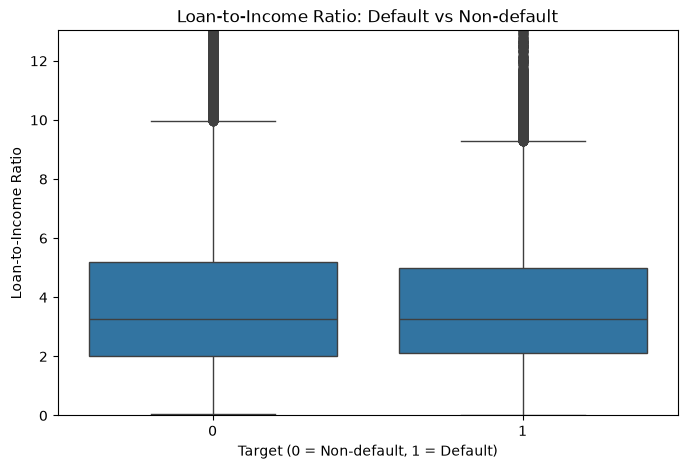

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="LOAN_INCOME_RATIO",
    data=df
)

plt.title("Loan-to-Income Ratio: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Loan-to-Income Ratio")

plt.ylim(0, df["LOAN_INCOME_RATIO"].quantile(0.99))

plt.show()

### Insight: Loan-to-Income Ratio and Loan Default

The loan-to-income ratio shows differences between defaulters and non-defaulters, although the two groups still have considerable overlap. A higher loan-to-income ratio may indicate a greater repayment burden relative to the applicant's income. This suggests that the loan-to-income ratio could be a useful feature for predicting loan default when combined with other financial and demographic variables.

In [19]:
df["EMPLOYMENT_YEARS"] = (-df["DAYS_EMPLOYED"]) / 365.25

print(df["EMPLOYMENT_YEARS"].describe())

count    307511.000000
mean       -174.716074
std         386.791969
min        -999.980835
25%           0.791239
50%           3.321013
75%           7.556468
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_8200\1884659261.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYMENT_YEARS"] = (-df["DAYS_EMPLOYED"]) / 365.25


In [20]:
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["EMPLOYMENT_YEARS"] = (
    -df["DAYS_EMPLOYED_CLEAN"] / 365.25
)

print(df["EMPLOYMENT_YEARS"].describe())

count    252137.000000
mean          6.527500
std           6.402081
min          -0.000000
25%           2.099932
50%           4.511978
75%           8.692676
max          49.040383
Name: EMPLOYMENT_YEARS, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_8200\4197777511.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)


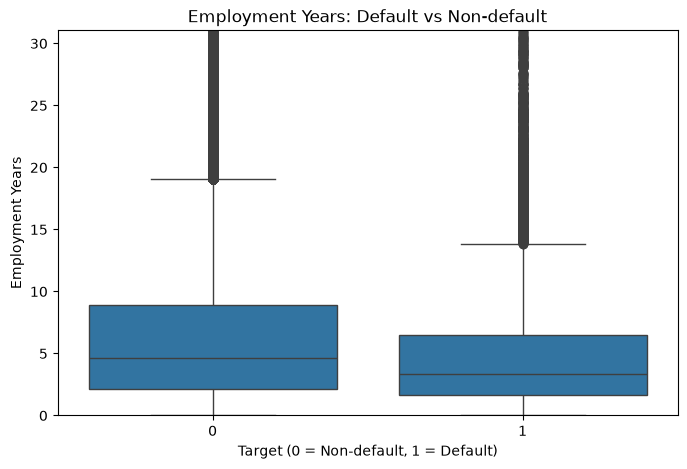

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="EMPLOYMENT_YEARS",
    data=df
)

plt.title("Employment Years: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Employment Years")

plt.ylim(0, df["EMPLOYMENT_YEARS"].quantile(0.99))

plt.show()

### Insight: Employment and Loan Default

Employment duration shows some differences between defaulters and non-defaulters, although the distributions overlap considerably. Applicants with shorter employment histories may have a different default risk compared with those with longer employment histories. This suggests that employment duration could provide useful information for predicting loan default when combined with other financial and demographic features.

In [22]:
children_summary = pd.crosstab(
    df["CNT_CHILDREN"],
    df["TARGET"],
    normalize="index"
) * 100

children_summary

TARGET,0,1
CNT_CHILDREN,,
0,92.288191,7.711809
1,91.076425,8.923575
2,91.278179,8.721821
3,90.368577,9.631423
4,87.179487,12.820513
5,91.666667,8.333333
6,71.428571,28.571429
7,100.000000,0.000000
8,100.000000,0.000000


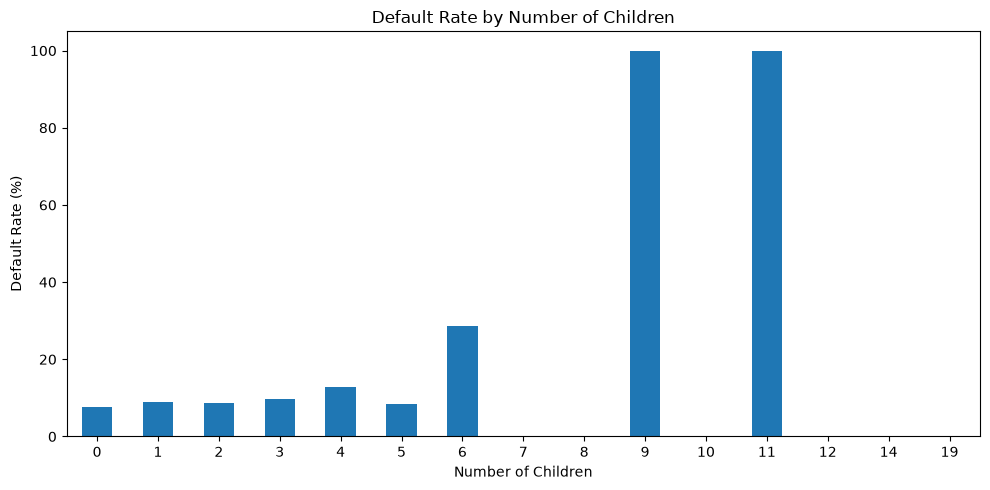

In [23]:
plt.figure(figsize=(10, 5))

children_summary[1].plot(
    kind="bar"
)

plt.title("Default Rate by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Insight: Number of Children and Loan Default

The default rate varies across different numbers of children, but the relationship is not strictly linear. Some categories show higher default rates than others, suggesting that household size may contain useful information for credit-risk prediction. However, categories with very few applicants should be interpreted carefully because their default rates may be less reliable.

In [24]:
family_summary = pd.crosstab(
    df["NAME_FAMILY_STATUS"],
    df["TARGET"],
    normalize="index"
) * 100

family_summary.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,90.055416,9.944584
Single / not married,90.192325,9.807675
Separated,91.805766,8.194234
Married,92.440132,7.559868
Widow,94.175783,5.824217
Unknown,100.000000,0.000000


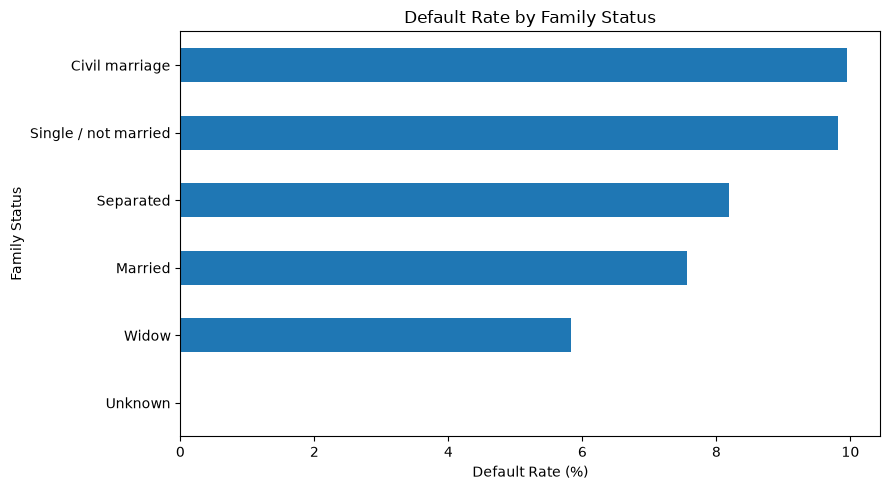

In [25]:
family_summary[1].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Default Rate by Family Status")
plt.xlabel("Default Rate (%)")
plt.ylabel("Family Status")
plt.tight_layout()

plt.show()

### Insight: Family Status and Loan Default

The default rate varies across family-status categories. Civil marriage and single applicants have relatively higher observed default rates, while married and widow applicants have lower rates. This suggests that family status may provide useful information for predicting loan default. However, these differences should be interpreted as associations in the dataset rather than causal relationships.

In [26]:
housing_summary = pd.crosstab(
    df["NAME_HOUSING_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

housing_summary.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
NAME_HOUSING_TYPE,,
Rented apartment,87.686949,12.313051
With parents,88.301887,11.698113
Municipal apartment,91.460252,8.539748
Co-op apartment,92.067736,7.932264
House / apartment,92.204289,7.795711
Office apartment,93.427589,6.572411


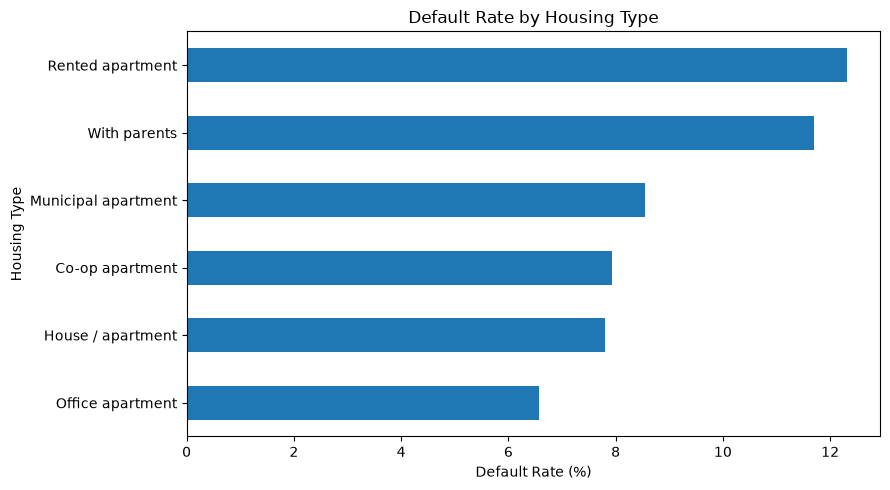

In [27]:
housing_summary[1].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Default Rate by Housing Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Housing Type")
plt.tight_layout()

plt.show()

### Insight: Housing Type and Loan Default

The default rate varies across housing types. Applicants living in rented apartments have the highest observed default rate (approximately 12.31%), followed by applicants living with parents (approximately 11.70%). Applicants living in office apartments have the lowest observed default rate (approximately 6.57%). This suggests that housing type may provide useful information for credit-risk prediction, although the observed relationship does not imply causation.

In [28]:
org_counts = df["ORGANIZATION_TYPE"].value_counts()

print("Number of organization categories:", len(org_counts))
print("\nTop 15 categories by applicant count:")
print(org_counts.head(15))

Number of organization categories: 58

Top 15 categories by applicant count:
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Name: count, dtype: int64


In [29]:
top_orgs = org_counts.head(15).index

org_default_rate = (
    df[df["ORGANIZATION_TYPE"].isin(top_orgs)]
    .groupby("ORGANIZATION_TYPE")["TARGET"]
    .mean()
    .mul(100)
    .sort_values()
)

org_default_rate

ORGANIZATION_TYPE
XNA                        5.399646
School                     5.914764
Medicine                   6.584472
Industry: type 9           6.680523
Government                 6.978085
Kindergarten               7.034884
Other                      7.642510
Business Entity Type 1     8.138369
Business Entity Type 2     8.528381
Transport: type 4          9.281215
Business Entity Type 3     9.299623
Trade: type 7              9.449623
Self-employed             10.173904
Trade: type 3             10.337915
Construction              11.679810
Name: TARGET, dtype: float64

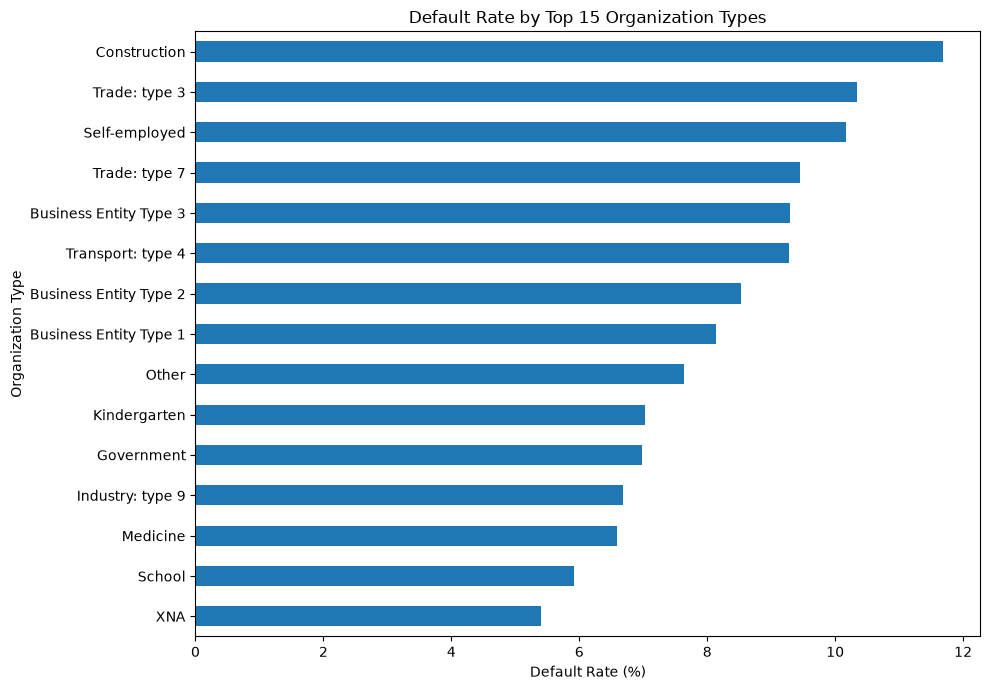

In [30]:
org_default_rate.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Default Rate by Top 15 Organization Types")
plt.xlabel("Default Rate (%)")
plt.ylabel("Organization Type")
plt.tight_layout()

plt.show()

### Insight: Organization Type and Loan Default

The observed default rate varies across organization types. Construction has the highest default rate among the selected top 15 categories (approximately 11.68%), followed by Trade: type 3 (approximately 10.34%) and Self-employed applicants (approximately 10.17%). School and Medicine have relatively lower observed default rates. This suggests that organization type may contain useful information for credit-risk prediction, although these are observed associations and do not imply causation.

In [31]:
income_type_summary = pd.crosstab(
    df["NAME_INCOME_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

income_type_summary.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
NAME_INCOME_TYPE,,
Maternity leave,60.000000,40.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472
Commercial associate,92.515743,7.484257
State servant,94.245035,5.754965
Pensioner,94.613634,5.386366
Businessman,100.000000,0.000000
Student,100.000000,0.000000


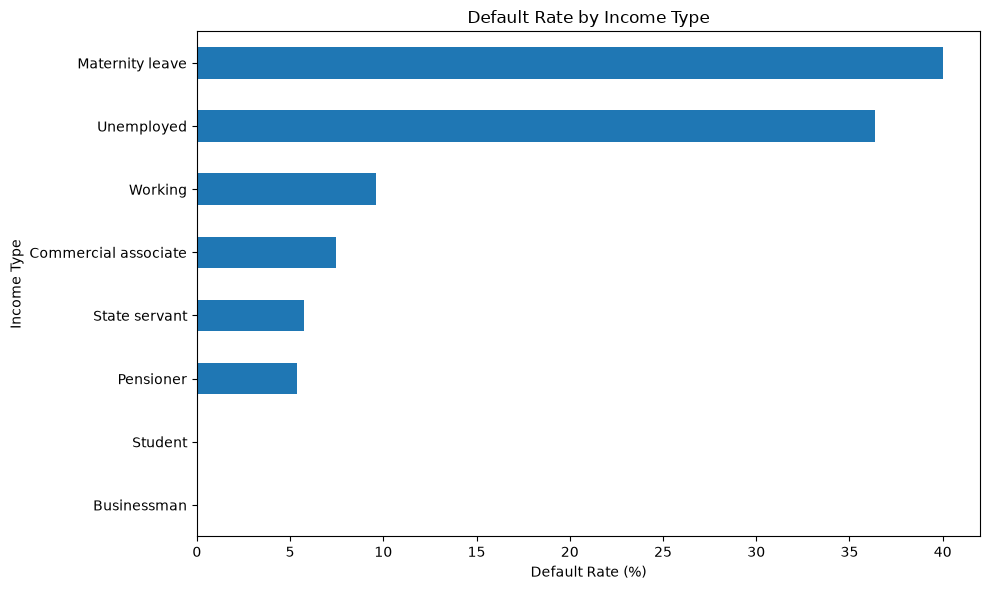

In [32]:
income_type_summary[1].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Default Rate by Income Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Income Type")
plt.tight_layout()

plt.show()

### Insight: Income Type and Loan Default

The observed default rate varies across income types. Working applicants have a relatively higher default rate (approximately 9.59%) compared with state servants (approximately 5.75%) and pensioners (approximately 5.39%). Maternity leave and unemployed categories show much higher observed default rates, but these categories contain relatively few applicants, so their rates should be interpreted cautiously. Overall, income type may provide useful information for credit-risk prediction.

In [33]:
occupation_summary = pd.crosstab(
    df["OCCUPATION_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

occupation_summary.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
OCCUPATION_TYPE,,
Low-skill Laborers,82.847587,17.152413
Drivers,88.673870,11.326130
Waiters/barmen staff,88.724036,11.275964
Security staff,89.257551,10.742449
Laborers,89.421230,10.578770
Cooking staff,89.556004,10.443996
Sales staff,90.368201,9.631799
Cleaning staff,90.393295,9.606705
Realty agents,92.143808,7.856192


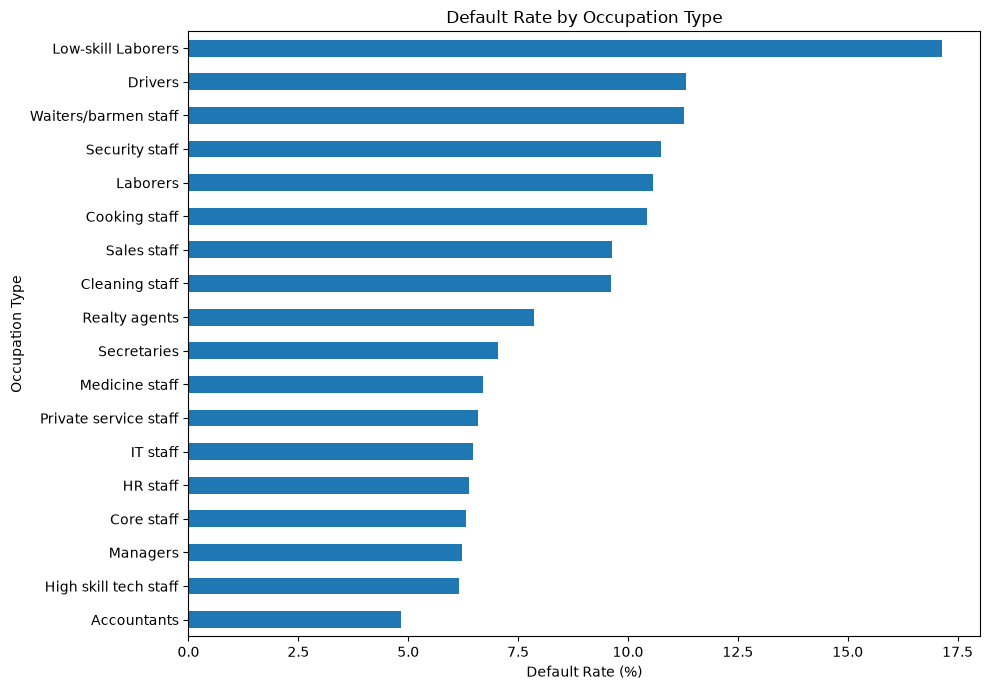

In [34]:
occupation_summary[1].sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Default Rate by Occupation Type")
plt.xlabel("Default Rate (%)")
plt.ylabel("Occupation Type")
plt.tight_layout()

plt.show()

### Insight: Occupation Type and Loan Default

The observed default rate varies across occupation types. Some occupations show noticeably higher default rates than others, suggesting that occupation may contain useful information about applicants' credit risk. However, categories with fewer applicants may have less stable default-rate estimates, so these differences should be interpreted cautiously.

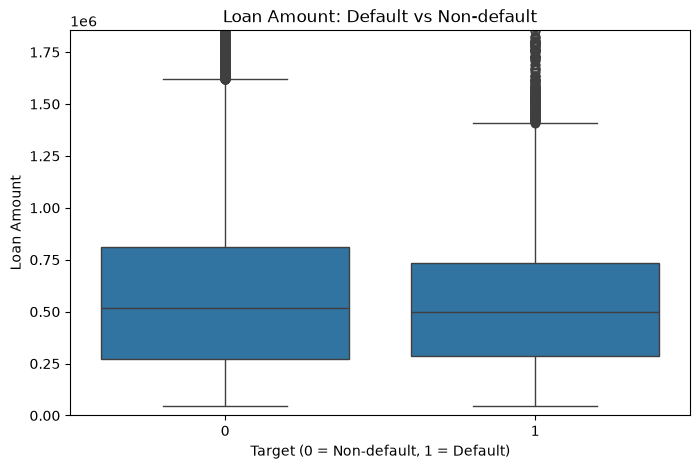

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="AMT_CREDIT",
    data=df
)

plt.title("Loan Amount: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Loan Amount")

plt.ylim(0, df["AMT_CREDIT"].quantile(0.99))

plt.show()

### Insight: Loan Amount and Loan Default

The loan amount distributions of defaulters and non-defaulters show considerable overlap, although their overall distributions may differ. This suggests that loan amount alone is not sufficient to predict default risk. The relationship between the loan amount and the applicant's income or other financial characteristics is likely to provide more useful information for credit-risk prediction.

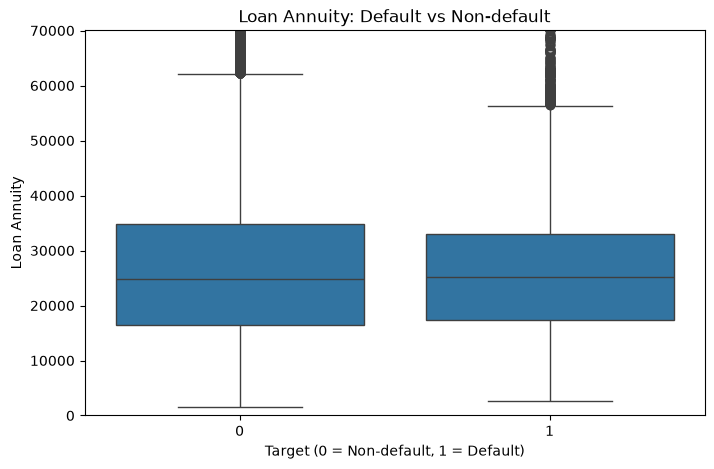

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="AMT_ANNUITY",
    data=df
)

plt.title("Loan Annuity: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Loan Annuity")

plt.ylim(0, df["AMT_ANNUITY"].quantile(0.99))

plt.show()

### Insight: Loan Annuity and Loan Default

The loan annuity distributions of defaulters and non-defaulters show considerable overlap. This indicates that the annuity amount alone is not sufficient to distinguish between the two groups. However, when combined with income and loan amount, repayment-related features such as annuity may provide useful information for predicting credit risk.

In [37]:
df["PAYMENT_BURDEN_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

print(df["PAYMENT_BURDEN_RATIO"].describe())

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: PAYMENT_BURDEN_RATIO, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_8200\2696173079.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["PAYMENT_BURDEN_RATIO"] = (


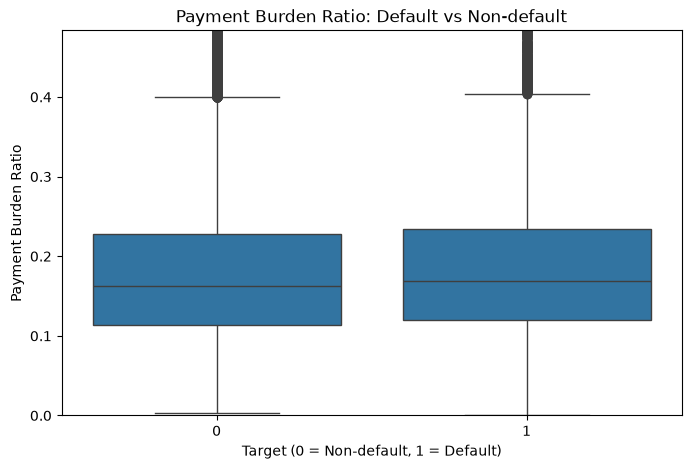

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="TARGET",
    y="PAYMENT_BURDEN_RATIO",
    data=df
)

plt.title("Payment Burden Ratio: Default vs Non-default")
plt.xlabel("Target (0 = Non-default, 1 = Default)")
plt.ylabel("Payment Burden Ratio")

plt.ylim(
    0,
    df["PAYMENT_BURDEN_RATIO"].quantile(0.99)
)

plt.show()

### Insight: Payment Burden Ratio and Loan Default

The payment burden ratio shows differences between defaulters and non-defaulters, although the distributions still overlap. A higher repayment burden relative to income may indicate greater financial pressure on the applicant. This suggests that the payment burden ratio could be a useful feature for predicting loan default when combined with other financial and demographic variables.

In [39]:
corr_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "LOAN_INCOME_RATIO",
    "PAYMENT_BURDEN_RATIO",
    "CNT_CHILDREN"
]

corr_matrix = df[corr_features].corr()

corr_matrix["TARGET"].sort_values(ascending=False)

TARGET                  1.000000
CNT_CHILDREN            0.019187
PAYMENT_BURDEN_RATIO    0.014265
AMT_INCOME_TOTAL       -0.003982
LOAN_INCOME_RATIO      -0.007727
AMT_ANNUITY            -0.012817
AMT_CREDIT             -0.030369
EMPLOYMENT_YEARS       -0.074958
AGE_YEARS              -0.078239
Name: TARGET, dtype: float64

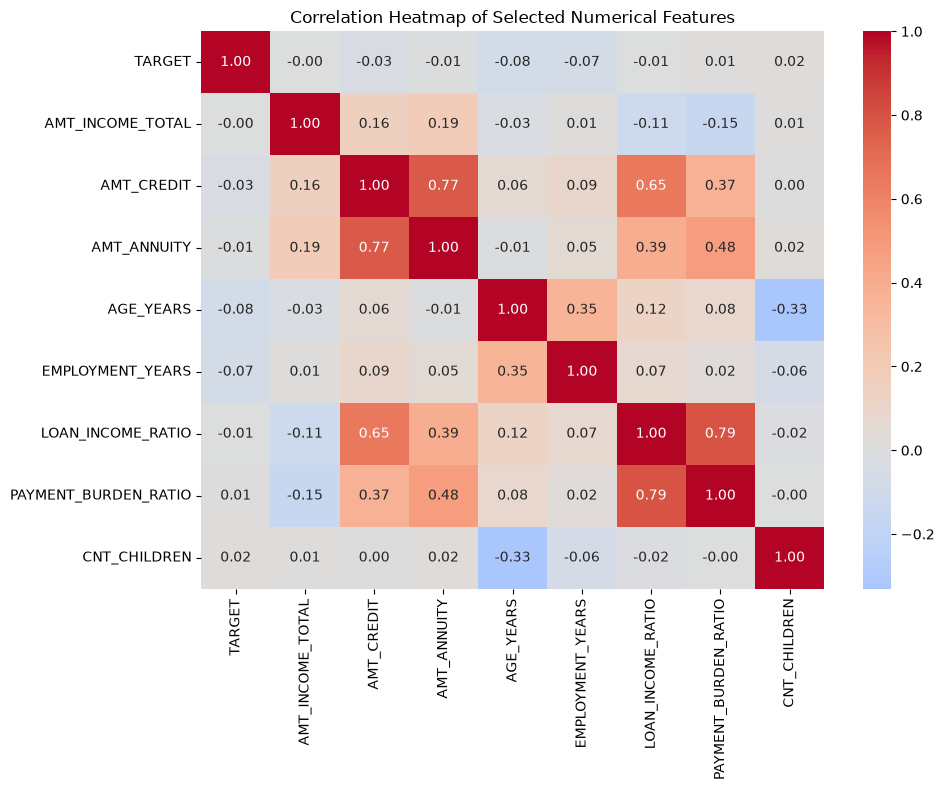

In [40]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Selected Numerical Features")
plt.tight_layout()

plt.show()

# Day 4 — Initial EDA Summary

### Key Findings

1. **Target imbalance:** The dataset has an overall default rate of approximately 8.07%, showing a clear class imbalance between defaulters and non-defaulters.

2. **Income:** Income distributions overlap considerably between the two target groups, suggesting that income alone is not sufficient to predict default.

3. **Age:** Older applicants generally show a slightly lower observed default tendency. Age may therefore provide useful predictive information.

4. **Employment:** Longer employment duration is associated with a slightly lower observed default tendency. Missing employment information was represented as `NaN`.

5. **Loan characteristics:** Loan amount, loan annuity, loan-to-income ratio, and payment burden show differences between groups but also considerable overlap.

6. **Demographic and categorical features:** Contract type, education, family status, housing type, income type, occupation, and organization type show differences in observed default rates across categories.

7. **Correlation:** The selected numerical features have relatively weak linear correlations with the target. This suggests that nonlinear relationships and combinations of features may be important for credit-risk prediction.

### Overall Conclusion

The EDA shows that loan default is influenced by multiple financial, demographic, employment, and loan-related characteristics rather than by a single variable. These findings will guide the feature-engineering and modeling stages of the project.